
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
​
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Amit Project for Data Science Module <br><br>💡💡💡💡💡 <br><br> DEPI_BS_DS_R3  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Project: Trip data Ford go bike  </h3></center>     
​
</div>

# Part I - Dataset Exploration for Ford GoBike

### Worked by: DEPI Data Science Team

## Introduction

This notebook explores individual rides from the Ford GoBike bike-sharing system in the San Francisco Bay Area during February 2019. The analysis covers data quality, trip duration, user demographics, membership behavior, and relationships among numeric variables.



> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 





# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [22]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sb
import seaborn as sns

%matplotlib inline

In [6]:
# Load my dataset using pandas Dataframe
df = pd.read_csv('./fordgobike-tripdataFor201902.csv')


In [7]:
# here we make overview in high-level for data shape and composition
df.head()



,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [8]:
## check each var  datatype 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

In [9]:
## I display 15 rows to understand the content values more 

df.head(15)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,49:58.6,19:51.8,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,55:35.1,14:42.6,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,41:06.8,08:02.8,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,41:48.8,07:59.7,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,49:47.7,07:17.0,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [10]:
# descriptive statistics for numeric variables
df.describe()


,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


> ### What is the structure of your dataset?

- The dataset contains **183,416 rows and 16 original columns**.
- It includes trip duration, timestamps, station identifiers and coordinates, bike identifiers, user type, birth year, gender, and bike-share membership.
- Numeric columns include duration, station IDs and coordinates, bike ID, and birth year. Categorical columns include user type, gender, and bike-share membership. Missing values occur mainly in station metadata and member demographics.

> ### What are the main interesting features in the dataset?

1. **Trip duration**, because it describes how customers use the service.
2. **User demographics**, especially user type, age, and gender.
3. **Station and bike-share information**, which can support operational and marketing decisions.

> ### What features supported my investigation?

- `duration_sec`, plus the derived `duration_min` and `duration_hours`.
- `user_type`, `member_gender`, and `bike_share_for_all_trip`.
- `member_birth_year`, converted into the derived `age` feature.
- Station IDs and `bike_id` for the numeric correlation checks.

##  More Exploring ideas to begin my investigation

In [26]:
# Statistical summary for numeric variables, including missing-value counts
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'unique_values': df.nunique(),
})
summary['missing_percent'] = (summary['missing_values'] / len(df) * 100).round(2)
summary

,dtype,missing_values,unique_values,missing_percent
duration_sec,int64,0,4752,0.0
start_time,str,0,35783,0.0
end_time,str,0,35767,0.0
start_station_id,float64,0,329,0.0
start_station_name,str,0,330,0.0
start_station_latitude,float64,0,334,0.0
start_station_longitude,float64,0,335,0.0
end_station_id,float64,0,329,0.0
end_station_name,str,0,330,0.0
end_station_latitude,float64,0,335,0.0


In [27]:
# display the information about each column
df.info()




<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183416 non-null  float64
 4   start_station_name       183416 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183416 non-null  float64
 8   end_station_name         183416 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        183416 non-null  float64
 14  member_gender  

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [28]:
# Display missing values and their percentages
missing = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2),
})
missing[missing['missing_values'] > 0].sort_values('missing_values', ascending=False)

,missing_values,missing_percent


> Numeric missing values are filled with the column median, while missing categorical values are labeled `Unknown`. This preserves all rows without inventing a new demographic category.

In [29]:
# Fill numeric columns with their median and categorical columns with 'Unknown'
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())
for column in categorical_columns:
    df[column] = df[column].fillna('Unknown')

df.isna().sum().sort_values(ascending=False).head()

/tmp/ipykernel_3485/4010842990.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


duration_sec          0
start_time            0
end_time              0
start_station_id      0
start_station_name    0
dtype: int64

In [30]:
# Check that no missing values remain
df.isna().sum().sum()

np.int64(0)

### **And with a proper category for other (member gender)**

In [31]:
# Inspect the categories in member_gender before final cleaning
df['member_gender'].value_counts(dropna=False)

member_gender
Male       130655
Female      40844
Unknown      8265
Other        3652
Name: count, dtype: int64

In [32]:
# Keep the explicit Unknown category for members whose gender was not recorded
df['member_gender'] = df['member_gender'].fillna('Unknown')
df['member_gender'].value_counts(dropna=False)

member_gender
Male       130655
Female      40844
Unknown      8265
Other        3652
Name: count, dtype: int64

In [33]:
df['member_gender'].value_counts(dropna=False)

member_gender
Male       130655
Female      40844
Unknown      8265
Other        3652
Name: count, dtype: int64

In [34]:
# Verify missing values and categorical values after cleaning
print('Total missing values:', int(df.isna().sum().sum()))
print('\nUser types:', df['user_type'].unique())
print('Genders:', df['member_gender'].unique())

Total missing values: 0

User types: <StringArray>
['Customer', 'Subscriber']
Length: 2, dtype: str
Genders: <StringArray>
['Male', 'Unknown', 'Other', 'Female']
Length: 4, dtype: str


> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [35]:
# Count exact duplicate rows
duplicate_count = int(df.duplicated().sum())
print('Duplicate rows:', duplicate_count)

Duplicate rows: 4


> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

The categorical columns are inspected below before converting them to categorical data types.

In [36]:
# Inspect categorical columns and their observed values
categorical_columns = df.select_dtypes(include='object').columns
for column in categorical_columns:
    print(f'{column}: {df[column].nunique()} unique values')
    print(df[column].value_counts(dropna=False).head(), '\n')

/tmp/ipykernel_3485/1759716449.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


start_time: 35783 unique values
start_time
12:19.2    16
33:48.5    16
56:50.8    16
07:52.7    15
07:21.5    15
Name: count, dtype: int64 

end_time: 35767 unique values
end_time
22:24.4    20
21:24.5    16
34:21.9    16
59:26.1    16
57:33.4    16
Name: count, dtype: int64 

start_station_name: 330 unique values
start_station_name
Market St at 10th St                                         3904
San Francisco Caltrain Station 2  (Townsend St at 4th St)    3544
Berry St at 4th St                                           3052
Montgomery St BART Station (Market St at 2nd St)             2896
Powell St BART Station (Market St at 4th St)                 2760
Name: count, dtype: int64 

end_station_name: 330 unique values
end_station_name
San Francisco Caltrain Station 2  (Townsend St at 4th St)    4857
Market St at 10th St                                         3973
Montgomery St BART Station (Market St at 2nd St)             3647
San Francisco Ferry Building (Harry Bridges Plaza)      

 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [37]:
# Store low-cardinality text fields as categorical data
df['user_type'] = df['user_type'].astype('category')
df['member_gender'] = df['member_gender'].astype('category')
df['bike_share_for_all_trip'] = df['bike_share_for_all_trip'].astype('category')
df[['user_type', 'member_gender', 'bike_share_for_all_trip']].dtypes

user_type                  category
member_gender              category
bike_share_for_all_trip    category
dtype: object

In [38]:
df[['user_type', 'member_gender', 'bike_share_for_all_trip']].head()

,user_type,member_gender,bike_share_for_all_trip
0,Customer,Male,No
1,Customer,Unknown,No
2,Customer,Male,No
3,Subscriber,Other,No
4,Subscriber,Male,Yes


In [39]:
# Estimate age from the recorded birth year using the dataset year
dataset_year = 2019
df['age'] = dataset_year - df['member_birth_year']
df[['member_birth_year', 'age']].head()

,member_birth_year,age
0,1984.0,35.0
1,1987.0,32.0
2,1972.0,47.0
3,1989.0,30.0
4,1974.0,45.0


In [40]:
df['age'].describe()

count    183416.000000
mean         34.094654
std           9.896492
min          18.000000
25%          27.000000
50%          32.000000
75%          38.000000
max         141.000000
Name: age, dtype: float64

In [14]:
df['age'] = df['age'].round().astype(int)
df['age'].dtype

dtype('int64')

In [41]:
def average_age(dataframe):
    return dataframe['age'].mean().round(1)

print(f'Average user age: {average_age(df)} years')

Average user age: 34.1 years


In [42]:
df['duration_min'] = df['duration_sec'] / 60
df['duration_min'].describe().round(2)

count    183416.00
mean         12.10
std          29.91
min           1.02
25%           5.42
50%           8.57
75%          13.27
max        1424.07
Name: duration_min, dtype: float64

In [43]:
df['duration_hours'] = df['duration_sec'] / 3600
df['duration_hours'].describe().round(2)

count    183416.00
mean          0.20
std           0.50
min           0.02
25%           0.09
50%           0.14
75%           0.22
max          23.73
Name: duration_hours, dtype: float64

In [44]:
df[['duration_sec', 'duration_min', 'duration_hours']].head()

,duration_sec,duration_min,duration_hours
0,52185,869.750000,14.495833
1,42521,708.683333,11.811389
2,61854,1030.900000,17.181667
3,36490,608.166667,10.136111
4,1585,26.416667,0.440278


The cleaned dataset is ready for univariate exploration.


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

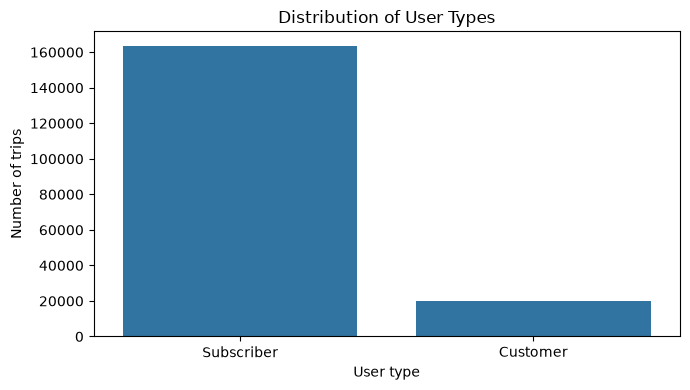

In [45]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='user_type', order=df['user_type'].value_counts().index)
plt.title('Distribution of User Types')
plt.xlabel('User type')
plt.ylabel('Number of trips')
plt.tight_layout()
plt.show()

> Subscribers make up the large majority of recorded trips, while customers represent a much smaller share. This suggests that the service is used primarily for regular commuting or repeated local travel.

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

> Most trips are not enrolled in the Bike Share for All program. The two-category comparison provides a useful baseline for evaluating adoption of that program.

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

> The age distribution is concentrated among adults in their twenties through forties. The older ages visible in the tail should be checked as potential data-quality outliers rather than interpreted as the typical customer profile.


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


> The boxplot and IQR rule identify unusually high ages. These values are retained for transparency, but they should be excluded or investigated before using age for precise targeting.

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

In [46]:
df['duration_min'].describe().round(2)

count    183416.00
mean         12.10
std          29.91
min           1.02
25%           5.42
50%           8.57
75%          13.27
max        1424.07
Name: duration_min, dtype: float64

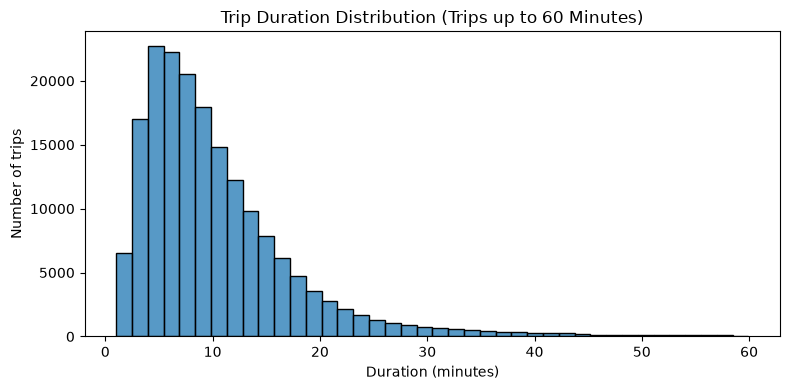

In [47]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df[df['duration_min'] <= 60], x='duration_min', bins=40)
plt.title('Trip Duration Distribution (Trips up to 60 Minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of trips')
plt.tight_layout()
plt.show()

> Trip duration is strongly right-skewed. Most rides are short, with the median below 10 minutes, while a small number of very long rides create the large maximum. The bounded histogram makes the common ride pattern easier to see.


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

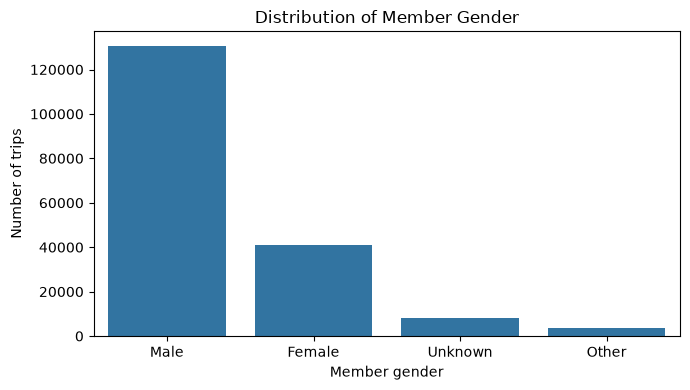

In [48]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='member_gender', order=df['member_gender'].value_counts().index)
plt.title('Distribution of Member Gender')
plt.xlabel('Member gender')
plt.ylabel('Number of trips')
plt.tight_layout()
plt.show()

> Male members account for the largest share of trips, followed by female members. A smaller Unknown group remains because gender was not recorded for some rides.

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

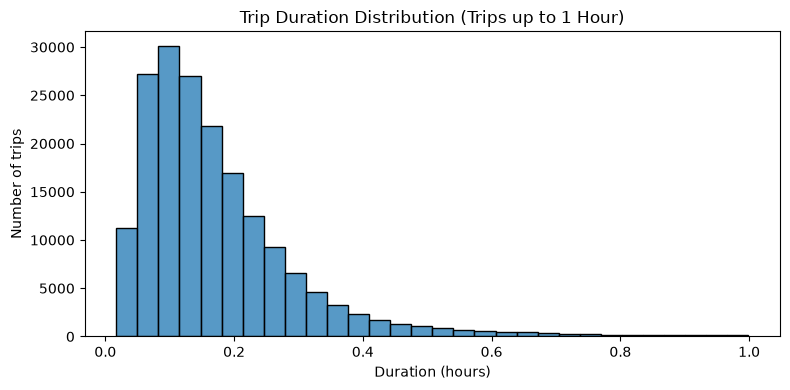

In [49]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df[df['duration_hours'] <= 1], x='duration_hours', bins=30)
plt.title('Trip Duration Distribution (Trips up to 1 Hour)')
plt.xlabel('Duration (hours)')
plt.ylabel('Number of trips')
plt.tight_layout()
plt.show()

> The hours distribution confirms that the typical ride is much shorter than one hour. The long tail is visible in the summary statistics but is suppressed in the bounded plot so the main distribution remains readable.

### The variables distribution:


> The distribution of duration present that most of the trips were less than 30 minutes ( we can notice that from the minutes and the hour charts )


> And the Age distribution is ( left Skewed ) as most users age are  22 - 39


> Most users are subscribers, not Customers and  Males as shown in the charts above.



### Were there any interesting and outliers 


- We got Age outliers for for more than 100 .



- The distribution of duration was strange where the minutes and the hour charts were 30 minutes or less.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

In [50]:
avg_duration_by_user = (df.groupby('user_type', observed=True)['duration_min']
                         .agg(['mean', 'median', 'count'])
                         .round(2))
avg_duration_by_user

,mean,median,count
user_type,,,
Customer,23.87,13.20,19868
Subscriber,10.67,8.17,163548


# Make visualization to easy get insight


> Customers have the higher average trip duration in this dataset, while subscribers have the lower median duration. The gap between mean and median shows that a small number of unusually long customer rides pull the customer mean upward.

# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

In [51]:
gender_duration = (df.groupby('member_gender', observed=True)['duration_min']
                   .agg(['mean', 'median', 'count'])
                   .sort_values('mean', ascending=False)
                   .round(2))
gender_duration

,mean,median,count
member_gender,,,
Unknown,19.82,10.10,8265
Other,16.61,9.25,3652
Female,12.98,9.47,40844
Male,11.21,8.22,130655


# Make visualization to easy get insight


> The gender groups have broadly similar short-trip behavior, but their means can differ because of the long duration tail. The Unknown group should be treated cautiously because it represents missing demographic information.

# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

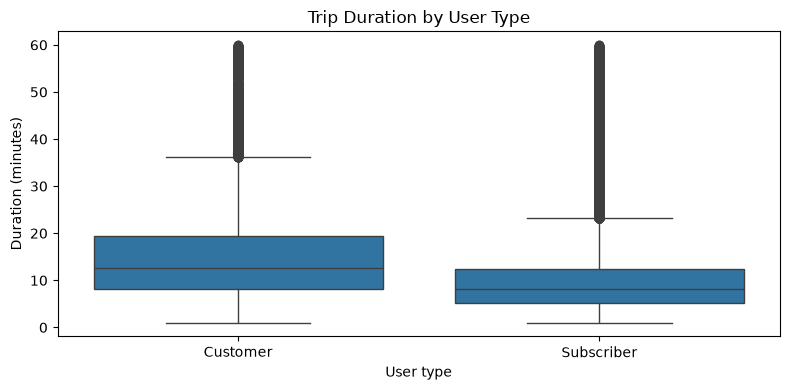

In [52]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[df['duration_min'] <= 60], x='user_type', y='duration_min')
plt.title('Trip Duration by User Type')
plt.xlabel('User type')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

> The boxplot shows the typical duration and the spread for each user type. Both groups contain short rides, while long rides appear as high-end outliers; the customer and subscriber distributions should therefore be compared using both median and mean.

# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

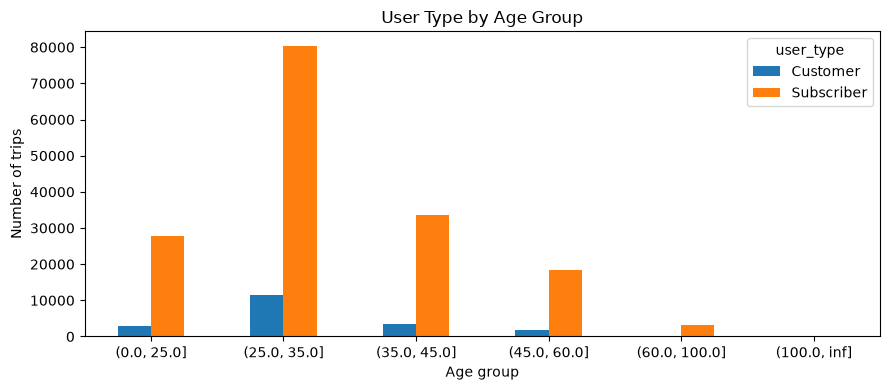

In [53]:
age_user_counts = pd.crosstab(pd.cut(df['age'], bins=[0, 25, 35, 45, 60, 100, np.inf]), df['user_type'])
ax = age_user_counts.plot(kind='bar', figsize=(9, 4))
ax.set_title('User Type by Age Group')
ax.set_xlabel('Age group')
ax.set_ylabel('Number of trips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> Subscribers appear across the main adult age groups and dominate each group because they are the dominant user type overall. Customers are less frequent, so their age pattern is less stable.

#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

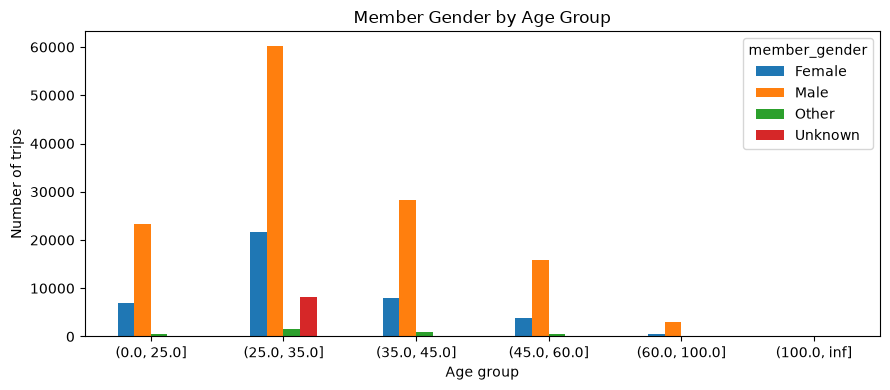

In [54]:
age_gender_counts = pd.crosstab(pd.cut(df['age'], bins=[0, 25, 35, 45, 60, 100, np.inf]), df['member_gender'])
ax = age_gender_counts.plot(kind='bar', figsize=(9, 4))
ax.set_title('Member Gender by Age Group')
ax.set_xlabel('Age group')
ax.set_ylabel('Number of trips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> Male members are the largest group across the principal age bands, followed by female members. The distribution is concentrated among adult users, while the Unknown group reflects unrecorded gender rather than a behavioral segment.

### Relationships observed

> Trip duration is strongly right-skewed for both user types and gender groups: most rides are short, but a small number of long rides increase the mean. Subscribers account for most rides across the major age groups, and the demographic counts are concentrated among adults.

### Other relationships

> `duration_sec`, `duration_min`, and `duration_hours` are mathematically equivalent, so their correlations are expected to be 1. Station IDs, bike IDs, and demographic variables show little meaningful linear relationship with duration. The negative relationship between birth year and age is expected because age is derived from birth year.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

In [20]:
# Prepare the numeric features used in the multivariate analysis
numeric_features = ['duration_sec', 'duration_min', 'duration_hours', 'start_station_id',
                    'end_station_id', 'bike_id', 'member_birth_year', 'age']
df[numeric_features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
duration_sec,183416.0,726.07,1794.37,61.00,325.00,514.00,796.00,85444.00
duration_min,183416.0,12.10,29.91,1.02,5.42,8.57,13.27,1424.07
duration_hours,183416.0,0.20,0.50,0.02,0.09,0.14,0.22,23.73
start_station_id,183416.0,138.55,111.72,3.00,47.00,104.00,239.00,398.00
end_station_id,183416.0,136.21,111.46,3.00,44.00,100.00,235.00,398.00
bike_id,183416.0,4472.89,1664.39,11.00,3777.00,4958.00,5502.00,6645.00
member_birth_year,183416.0,1984.91,9.90,1878.00,1981.00,1987.00,1992.00,2001.00
age,183416.0,34.09,9.90,18.00,27.00,32.00,38.00,141.00



# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

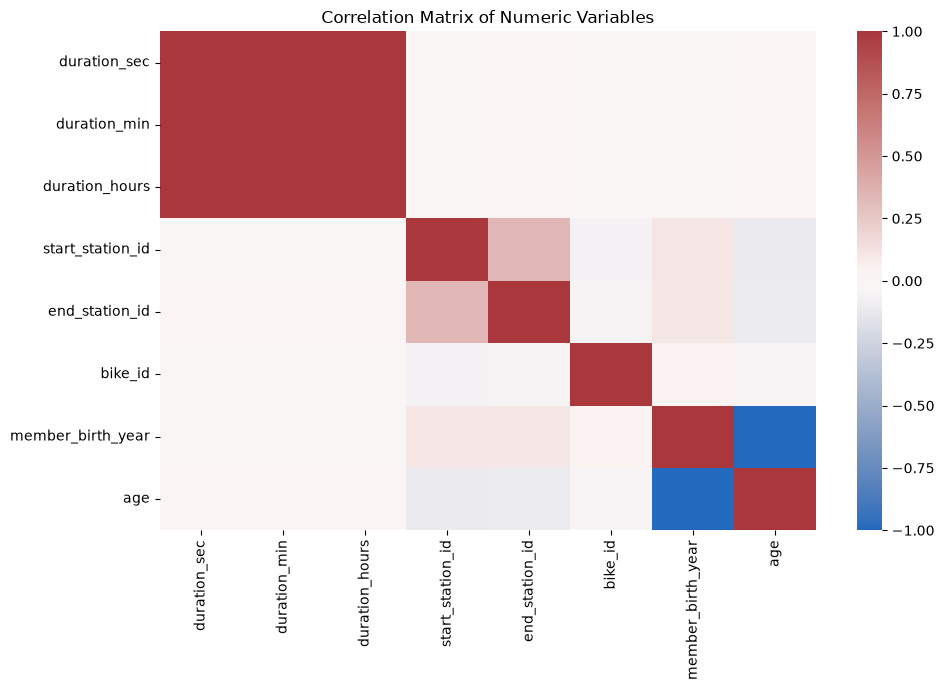

In [23]:
correlation_matrix = df[numeric_features].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, cmap='vlag', center=0, annot=False)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

> The heatmap shows the expected perfect correlation among the three duration representations because they are direct unit conversions. Other numeric variables have weak relationships with trip duration, while age and birth year have a strong negative relationship because age was calculated from birth year.


# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


In [24]:
selected_features = ['duration_min', 'age', 'member_birth_year', 'bike_id',
                     'start_station_id', 'end_station_id']
selected_correlation = df[selected_features].corr().round(2)
selected_correlation

,duration_min,age,member_birth_year,bike_id,start_station_id,end_station_id
duration_min,1.00,0.00,-0.00,-0.01,-0.01,0.00
age,0.00,1.00,-1.00,-0.03,-0.11,-0.11
member_birth_year,-0.00,-1.00,1.00,0.03,0.11,0.11
bike_id,-0.01,-0.03,0.03,1.00,-0.06,-0.05
start_station_id,-0.01,-0.11,0.11,-0.06,1.00,0.34
end_station_id,0.00,-0.11,0.11,-0.05,0.34,1.00


> The selected-variable heatmap confirms that duration has little linear correlation with bike or station IDs. Age and birth year show a strong negative correlation by construction, and station IDs should be treated as labels rather than continuous measurements.

# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


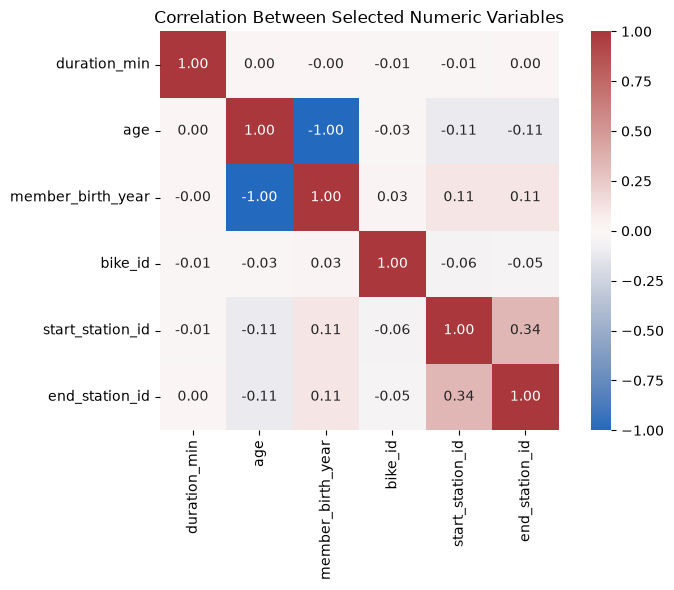

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(selected_correlation, annot=True, fmt='.2f', cmap='vlag', center=0, square=True)
plt.title('Correlation Between Selected Numeric Variables')
plt.tight_layout()
plt.show()

> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>



**Actually the `heat map`  display the above ideas in clear percentages**



- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- There is a `negative  Correlation` between  member_birth_year  and age which normal.




- There is `no significant Correlation` for any variable with `bike_id `



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

- The dataset contains 183,416 Ford GoBike trips from February 2019.
- Subscribers account for most trips, and male members are the largest recorded gender group.
- The typical ride is short, with a median duration of about 8.6 minutes; the duration distribution is strongly right-skewed.
- Users are concentrated in adult age groups, but unusually high ages should be investigated before targeting campaigns.
- Correlations among duration units are mathematical duplicates, while most operational and demographic variables have weak linear relationships with trip duration.

## Limitations

- Missing demographic and station values were retained through median or `Unknown` imputation, so those records should be interpreted carefully.
- The analysis describes one month of activity and may not represent other seasons.
- Station and bike IDs are identifiers, not naturally continuous numeric measures, so their correlations have limited business meaning.

End of the Ford GoBike exploratory data analysis.

In [58]:
# Complete cleaning pipeline and export the final dataset
# This cell handles blanks, nulls, duplicates, data types, and outliers.
df_cleaned = df.copy()
original_rows = len(df_cleaned)

# Convert blank text values to missing values, then use an explicit category.
text_columns = df_cleaned.select_dtypes(include=['object', 'string', 'category']).columns
for column in text_columns:
    df_cleaned[column] = df_cleaned[column].astype('string').str.strip()
    df_cleaned[column] = df_cleaned[column].replace('', pd.NA).fillna('Unknown')

# The source stores start_time and end_time as elapsed-style strings such as 32:10.1.
# Keep them as cleaned strings instead of incorrectly parsing them as calendar dates.

# Convert numeric fields explicitly; invalid values become missing.
numeric_columns = [
    'duration_sec', 'start_station_id', 'start_station_latitude',
    'start_station_longitude', 'end_station_id', 'end_station_latitude',
    'end_station_longitude', 'bike_id', 'member_birth_year'
]
for column in numeric_columns:
    df_cleaned[column] = pd.to_numeric(df_cleaned[column], errors='coerce')

# Fill numeric missing values with medians and categorical missing values with Unknown.
for column in numeric_columns:
    df_cleaned[column] = df_cleaned[column].fillna(df_cleaned[column].median())
for column in text_columns:
    df_cleaned[column] = df_cleaned[column].fillna('Unknown')

# Remove exact duplicate records before calculating outlier limits.
rows_before_duplicates = len(df_cleaned)
df_cleaned = df_cleaned.drop_duplicates().copy()
duplicates_removed = rows_before_duplicates - len(df_cleaned)

# Use integer nullable types for identifier and birth-year columns.
for column in ['start_station_id', 'end_station_id', 'bike_id', 'member_birth_year']:
    df_cleaned[column] = df_cleaned[column].round().astype('Int64')

# Recalculate derived fields from the cleaned source columns.
df_cleaned['age'] = (2019 - df_cleaned['member_birth_year']).astype('Int64')
df_cleaned['duration_min'] = df_cleaned['duration_sec'] / 60
df_cleaned['duration_hours'] = df_cleaned['duration_sec'] / 3600

# Remove age and trip-duration outliers using the IQR rule.
age_q1, age_q3 = df_cleaned['age'].quantile([0.25, 0.75])
age_iqr = age_q3 - age_q1
age_lower = max(18, age_q1 - 1.5 * age_iqr)
age_upper = min(100, age_q3 + 1.5 * age_iqr)

duration_q1, duration_q3 = df_cleaned['duration_sec'].quantile([0.25, 0.75])
duration_iqr = duration_q3 - duration_q1
duration_lower = max(0, duration_q1 - 1.5 * duration_iqr)
duration_upper = duration_q3 + 1.5 * duration_iqr

outlier_mask = (
    df_cleaned['age'].between(age_lower, age_upper)
    & df_cleaned['duration_sec'].between(duration_lower, duration_upper)
)
rows_before_outliers = len(df_cleaned)
df_cleaned = df_cleaned.loc[outlier_mask].copy()
outliers_removed = rows_before_outliers - len(df_cleaned)

# Export without the pandas index and verify the final result.
output_path = './fordgobike-tripdataFor201902_cleaned.csv'
df_cleaned.to_csv(output_path, index=False)

blank_text_values = int(
    df_cleaned.select_dtypes(include=['object', 'string'])
    .apply(lambda column: column.str.strip().eq('').sum())
    .sum()
)
print(f'Original rows: {original_rows:,}')
print(f'Duplicates removed: {duplicates_removed:,}')
print(f'Outliers removed: {outliers_removed:,}')
print(f'Final rows: {len(df_cleaned):,}')
print(f'Null values remaining: {int(df_cleaned.isna().sum().sum())}')
print(f'Blank text values remaining: {blank_text_values}')
print(f'Age bounds: {age_lower:.1f} to {age_upper:.1f} years')
print(f'Duration bounds: {duration_lower:.1f} to {duration_upper:.1f} seconds')
print(f'Saved cleaned data to: {output_path}')

Original rows: 183,416
Duplicates removed: 4
Outliers removed: 18,466
Final rows: 164,946
Null values remaining: 0
Blank text values remaining: 0
Age bounds: 18.0 to 54.5 years
Duration bounds: 0.0 to 1502.5 seconds
Saved cleaned data to: ./fordgobike-tripdataFor201902_cleaned.csv
